=== START PROCESU ANNLITYCZNEGO ===
-> Baza (10m) ma wymiary: 1920 x 2500
-> Centrowanie danych (obliczanie średniej)...
-> Tworzenie macierzy kowariancji (X.T @ X)...
-> Uruchamiam Metodę Potęgową...
 Pomyślnie wyciągnięto składową PC1
 Pomyślnie wyciągnięto składową PC2
 Pomyślnie wyciągnięto składową PC3
-> Matematyczne rzutowanie danych na nowe osie...
-> Poprawiam kontrast obrazu metodą percentylową...


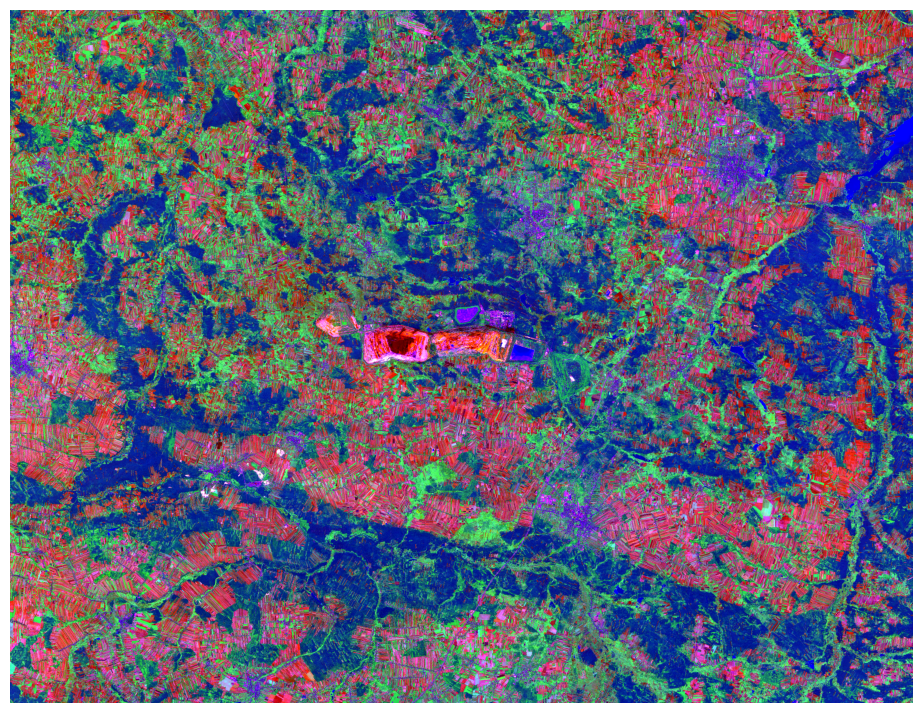

In [5]:
import numpy as np
# Ładujemy nasz autorski silnik matematyczny
from pca_utils import wlasne_pca
# Ładujemy naszą kompletną paczkę narzędzi graficzno-danych
from data_utils import (
    stworz_macierz_3d_z_resamplingiem, 
    rozciagnij_na_2d, 
    przywroc_format_obrazka, 
    zaawansowana_normalizacja_kontrastu,
    wyswietl_mape
)

# 1. Ścieżki do sprawnych plików
sciezki_10m = [
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B02_(Raw).tiff",
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B03_(Raw).tiff",
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B04_(Raw).tiff",
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B05_(Raw).tiff",
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B08_(Raw).tiff"
]

sciezki_20m = [
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B8A_(Raw).tiff",
    "data/belchatow/2025-08-14-00_00_2025-08-14-23_59_Sentinel-2_L2A_B12_(Raw).tiff"
]

print("=== START PROCESU ANNLITYCZNEGO ===")

# KROK 1: Przygotowanie 6-kanałowej kostki danych
kostka = stworz_macierz_3d_z_resamplingiem(sciezki_10m, sciezki_20m)
tabela_2d, wymiary = rozciagnij_na_2d(kostka)

# KROK 2: Analiza naszym autorskim algorytmem SVD (Metoda Potęgowa + Deflacjia)
wynik_pca_2d = wlasne_pca(tabela_2d, liczba_skladowych=3)

# KROK 3: Rekonstrukcja obrazu przestrzennego
obraz_pca_3d = przywroc_format_obrazka(wynik_pca_2d, wymiary)

# KROK 4: Profesjonalne podciąganie kontrastu (odcięcie 2% szumu kopalni)
mapa_rgb = zaawansowana_normalizacja_kontrastu(obraz_pca_3d, dolny_percentyl=2, gorny_percentyl=98)

# KROK 5: Wyświetlenie gotowego dzieła sztuki inżynierskiej z pełną legendą
wyswietl_mape(mapa_rgb)

=== START PROCESU ANNLITYCZNEGO ===
-> Baza (10m) ma wymiary: 1553 x 2500
-> Centrowanie danych (obliczanie średniej)...
-> Tworzenie macierzy kowariancji (X.T @ X)...
-> Uruchamiam Metodę Potęgową...
 Pomyślnie wyciągnięto składową PC1
 Pomyślnie wyciągnięto składową PC2
 Pomyślnie wyciągnięto składową PC3
-> Matematyczne rzutowanie danych na nowe osie...
-> Poprawiam kontrast obrazu metodą percentylową...


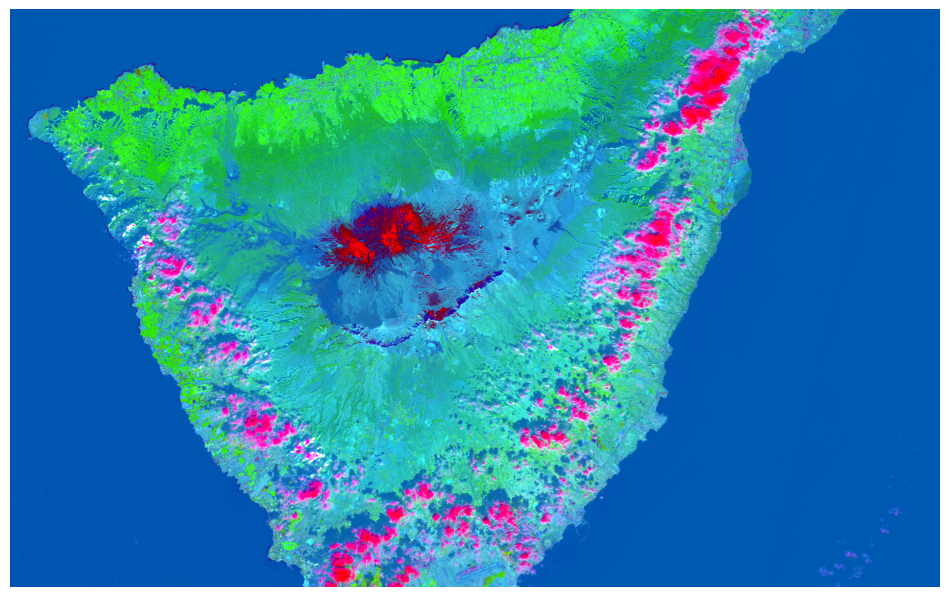

In [2]:
import numpy as np
from pca_utils import wlasne_pca
from data_utils import (
    stworz_macierz_3d_z_resamplingiem, 
    rozciagnij_na_2d, 
    przywroc_format_obrazka, 
    zaawansowana_normalizacja_kontrastu,
    wyswietl_mape
)

folder = "C:/Users/Igor/Desktop/studia/sentinel2-pca/data/teneryfa/2025-12-30-00_00_2025-12-30-23_59_Sentinel-2_L2A_"

sciezki_wszystkie = [folder + "B02_(Raw).tiff", folder + "B03_(Raw).tiff", folder + "B04_(Raw).tiff", folder + "B05_(Raw).tiff", folder + "B08_(Raw).tiff", folder + "B11_(Raw).tiff", folder + "B12_(Raw).tiff"]

#sciezki_wszystkie = [folder + "B01_(Raw).tiff", folder + "B02_(Raw).tiff", folder + "B03_(Raw).tiff", folder + "B04_(Raw).tiff", folder + "B05_(Raw).tiff",
#               folder + "B06_(Raw).tiff", folder + "B07_(Raw).tiff", folder + "B08_(Raw).tiff", folder + "B8A_(Raw).tiff", folder + "B09_(Raw).tiff",
#               folder + "B11_(Raw).tiff", folder + "B12_(Raw).tiff"]

print("=== START PROCESU ANNLITYCZNEGO ===")

kostka = stworz_macierz_3d_z_resamplingiem(sciezki_wszystkie, [])
tabela_2d, wymiary = rozciagnij_na_2d(kostka)
wynik_pca_2d = wlasne_pca(tabela_2d, liczba_skladowych=3)
obraz_pca_3d = przywroc_format_obrazka(wynik_pca_2d, wymiary)
mapa_rgb = zaawansowana_normalizacja_kontrastu(obraz_pca_3d, dolny_percentyl=2, gorny_percentyl=98)

wyswietl_mape(mapa_rgb)